<a href="https://colab.research.google.com/github/Mohul005/BioPulse/blob/main/PulseSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install pandas
!pip install joblib
!pip install numpy
!pip install matplotlib


In [8]:
!pip install scikit-learn

In [9]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Loading the dataset
df = pd.read_csv("Synthetic_Dataset.csv")

# Features
X = df[['avg_bpm','max_bpm','min_bpm','std_bpm']]

# Labels
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# FNN Generation
model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    max_iter=1000,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Test
predictions = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, predictions))

# Save model
joblib.dump(model, "PulseSense_FNN.pkl")

print("Model saved.")

Accuracy: 0.45
Model saved.


Instantaneous BPM Values:
[75.]


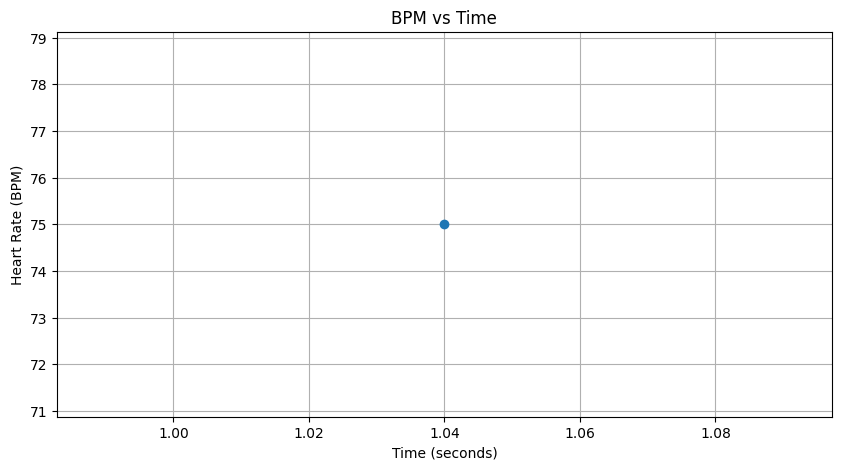

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Sampling Rate (Hz)
fs = 100


# Enter PPG Values Here


ppg = input("enter list og ppg values?")
ppg = np.array(ppg)

# ===========================
# Time Axis
# ===========================
time = np.arange(len(ppg)) / fs

# ===========================
# Peak Detection
# ===========================
peaks, _ = find_peaks(
    ppg,
    distance=5,
    prominence=10
)

# ===========================
# Check if Enough Peaks Exist
# ===========================
if len(peaks) < 2:
    print("Not enough peaks detected to calculate BPM.")
else:

    # Peak Times
    peak_times = time[peaks]

    # Time interval between consecutive peaks
    intervals = np.diff(peak_times)

    # BPM Calculation
    bpm_values = 60 / intervals

    print("Instantaneous BPM Values:")
    print(np.round(bpm_values, 2))


    # BPM vs Time Graph
    plt.figure(figsize=(10,5))

    plt.plot(
        peak_times[1:],
        bpm_values,
        marker='o',
        linewidth=2
    )

    plt.title("BPM vs Time")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Heart Rate (BPM)")

    plt.grid(True)

    plt.show()

In [11]:
avg_bpm = np.mean(bpm_values)
max_bpm = np.max(bpm_values)
min_bpm = np.min(bpm_values)
std_bpm = np.std(bpm_values)

patient_data = [[
    avg_bpm,
    max_bpm,
    min_bpm,
    std_bpm
]]

print(patient_data)

[[np.float64(299.9056081762848), np.float64(333.33333333333326), np.float64(272.72727272727275), np.float64(24.977801298133073)]]


In [12]:
import joblib

model = joblib.load(
    "PulseSense_FNN.pkl"
)

prediction = model.predict(
    patient_data
)[0]

labels = {
    0: "Bradycardia",
    1: "Normal",
    2: "Tachycardia"
}

print(
    "Prediction:",
    labels[prediction]
)

Prediction: Bradycardia


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [13]:
from google.colab import ai
prompt = f"""
A pulse monitoring system produced:

Average BPM: {avg_bpm}
Maximum BPM: {max_bpm}
Minimum BPM: {min_bpm}
Standard Deviation: {std_bpm}

FNN Prediction: {prediction}

Explain:
1. What this condition means.
2. Common causes.
3. Common symptoms.
4. Whether medical consultation is recommended.
5. Explain in simple language.

Do not claim a diagnosis.
State that this is only an AI-generated interpretation.
"""
response= ai.generate_text(prompt)
print(response)

### **Disclaimer**
*This is an AI-generated interpretation of data and does not constitute a medical diagnosis, clinical opinion, or a substitute for professional medical advice.*

---

### **1. What This Condition Means**
The pulse monitoring data indicates an **extremely fast heart rate** (tachycardia). 

* **The Numbers:** An average heart rate of nearly 300 beats per minute (BPM), with peaks up to 333 BPM, is critically high. For context, a normal resting heart rate for most adults is between 60 and 100 BPM. 
* **The "FNN Prediction: 0":** In machine learning and medical classification models, a output of "0" or "1" is a binary label. Depending on how this specific software was programmed, "0" usually represents a specific category (such as "Normal" or "Arrhythmia/Abnormal"). However, regardless of the AI's label, **physiologically, a heart rate of 300+ BPM is highly abnormal and dangerous.**
* **What is happening:** At speeds of 300 BPM, the heart is beating so fast that its chamb